In [18]:
# ============================================================
# Day 33 终极练习 —— ① 拉数据：3只股票（近2年，中美混搭）
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import akshare as ak

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

START, END = '2024-09-25', '2026-09-25'
COLS = ['open', 'high', 'low', 'close', 'volume']


def fetch_a(symbol):
    """A股：前复权(qfq)，akshare 可直接限定日期范围"""
    d = ak.stock_zh_a_daily(symbol=symbol, adjust='qfq',
                            start_date=START.replace('-', ''),
                            end_date=END.replace('-', ''))
    d['date'] = pd.to_datetime(d['date'])
    return d.set_index('date').sort_index()[COLS]


def fetch_us(symbol):
    """美股：新浪源不给日期参数，只能拉全量再自己切。一样要 qfq"""
    d = ak.stock_us_daily(symbol=symbol, adjust='qfq')
    d['date'] = pd.to_datetime(d['date'])
    return d.set_index('date').sort_index().loc[START:END, COLS]


stocks = {
    '宁德时代': fetch_a('sz300750'),   # 换掉茅台，用一只没碰过的
    'AAPL':    fetch_us('AAPL'),
    'NVDA':    fetch_us('NVDA'),
}

# 自检：列名 / 缺失值 / 日期范围
for name, d in stocks.items():
    assert d.columns.tolist() == COLS, f'{name} 列名不对: {d.columns.tolist()}'
    assert d.isna().sum().sum() == 0, f'{name} 有缺失值'
    print(f"{name:8s} shape={str(d.shape):11s} "
          f"{d.index.min().date()} → {d.index.max().date()}")


宁德时代     shape=(486, 5)    2024-09-25 → 2026-09-24
AAPL     shape=(502, 5)    2024-09-25 → 2026-09-25
NVDA     shape=(502, 5)    2024-09-25 → 2026-09-25


In [19]:
for name, d in stocks.items():

    # ---- MA ----
    d['MA5']  = d['close'].rolling(5).mean()    # ← 示范，就是你写的那行
    d['MA10'] = d['close'].rolling(10).mean()                              # 改个数字
    d['MA20'] = d['close'].rolling(20).mean()
    d['MA60'] = d['close'].rolling(60).mean()

    # ---- MACD ----
    ema12 = d['close'].ewm(span=12,adjust=False).mean()
    ema26 = d['close'].ewm(span=26,adjust=False).mean()
    d['DIF']  = ema12 - ema26    # EMA12 − EMA26
    d['DEA']  = d['DIF'].ewm(span=9,adjust=False).mean()    # DIF 的 EMA9
    d['MACD'] = (d['DIF'] - d['DEA']) * 2    # (DIF − DEA) × 2

    # ---- RSI ----
    日涨跌 = d['close'].diff()
    涨 = 日涨跌.clip(lower=0)
    跌 = 日涨跌.clip(upper=0).abs()
    rs = 涨.rolling(14).mean()/跌.rolling(14).mean()
    d['RSI14'] = 100 - 100/(1 + rs)

    # ---- 布林带 ----
    d['BOLL_MID'] = d['close'].rolling(20).mean()   # MA20

    σ = d['close'].rolling(20).std()
    
    d['BOLL_UP']  = d['BOLL_MID'] + 2 * σ   # 中轨 + 2σ
    d['BOLL_DN']  = d['BOLL_MID'] - 2 * σ   # 中轨 − 2σ
    
    print(f"\n===== {name} =====")      # ← 加上名字，输出才有身份
    print(d[['DIF','DEA','MACD','RSI14']].tail(3).round(6))

#print(stocks['AAPL'][['DIF','DEA','MACD','RSI14']].tail(3))
#print("\nDIF 的 dtype:", stocks['AAPL']['DIF'].dtype)


===== 宁德时代 =====
                  DIF        DEA      MACD      RSI14
date                                                 
2026-09-22 -20.356667 -16.980338 -6.752658  23.532978
2026-09-23 -20.356910 -17.655652 -5.402516  21.436985
2026-09-24 -20.723404 -18.269202 -4.908402  18.371837

===== AAPL =====
                 DIF       DEA      MACD      RSI14
date                                               
2026-09-23  6.207747  5.004815  2.405863  62.438119
2026-09-24  6.017697  5.207391  1.620611  58.320742
2026-09-25  6.211045  5.408122  1.605847  74.398705

===== NVDA =====
                 DIF       DEA      MACD      RSI14
date                                               
2026-09-23  2.196922  1.722197  0.949449  51.179751
2026-09-24  2.236635  1.825085  0.823100  45.552746
2026-09-25  2.281349  1.916337  0.730023  43.715847


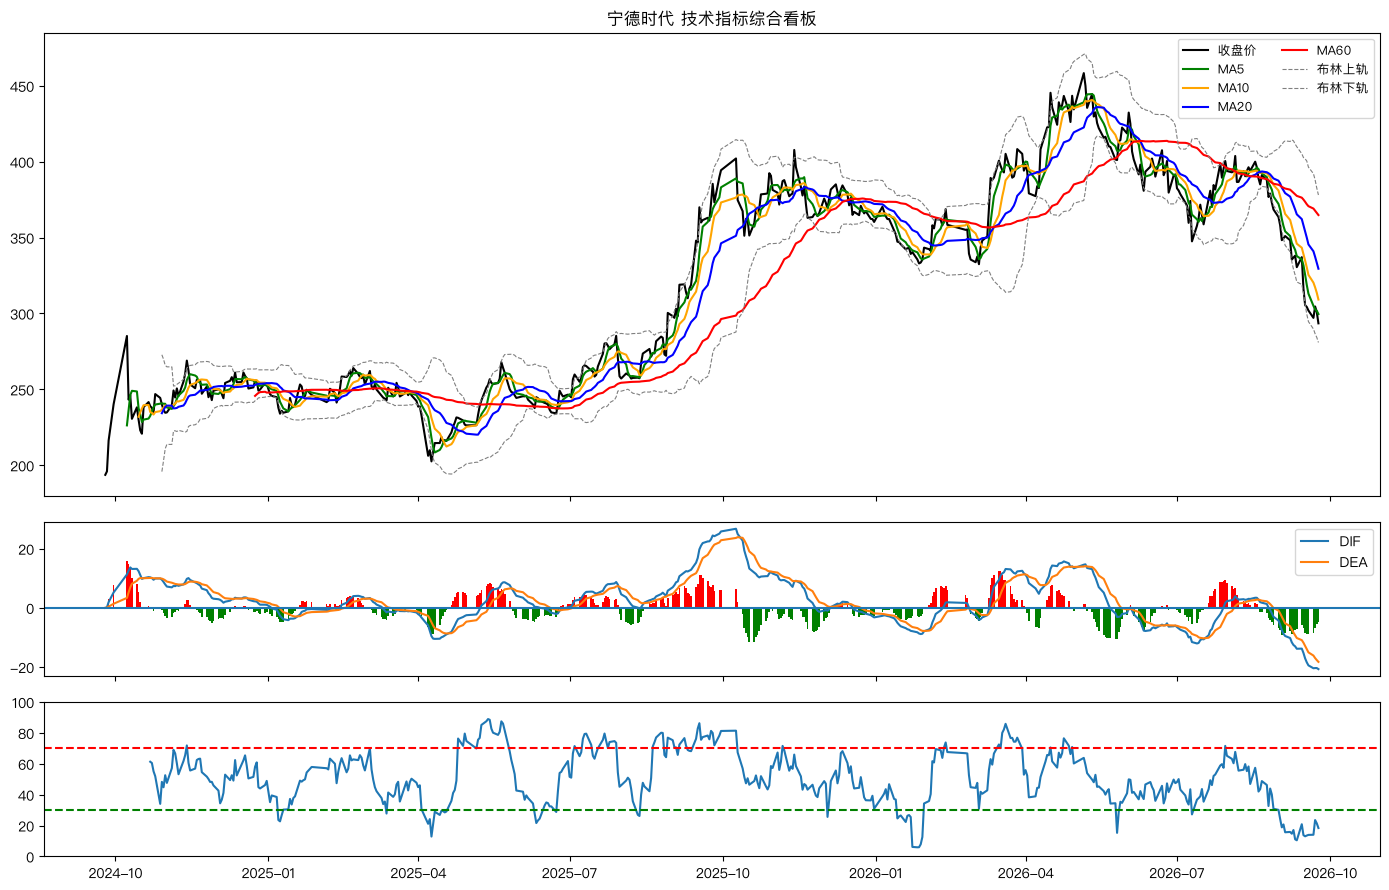

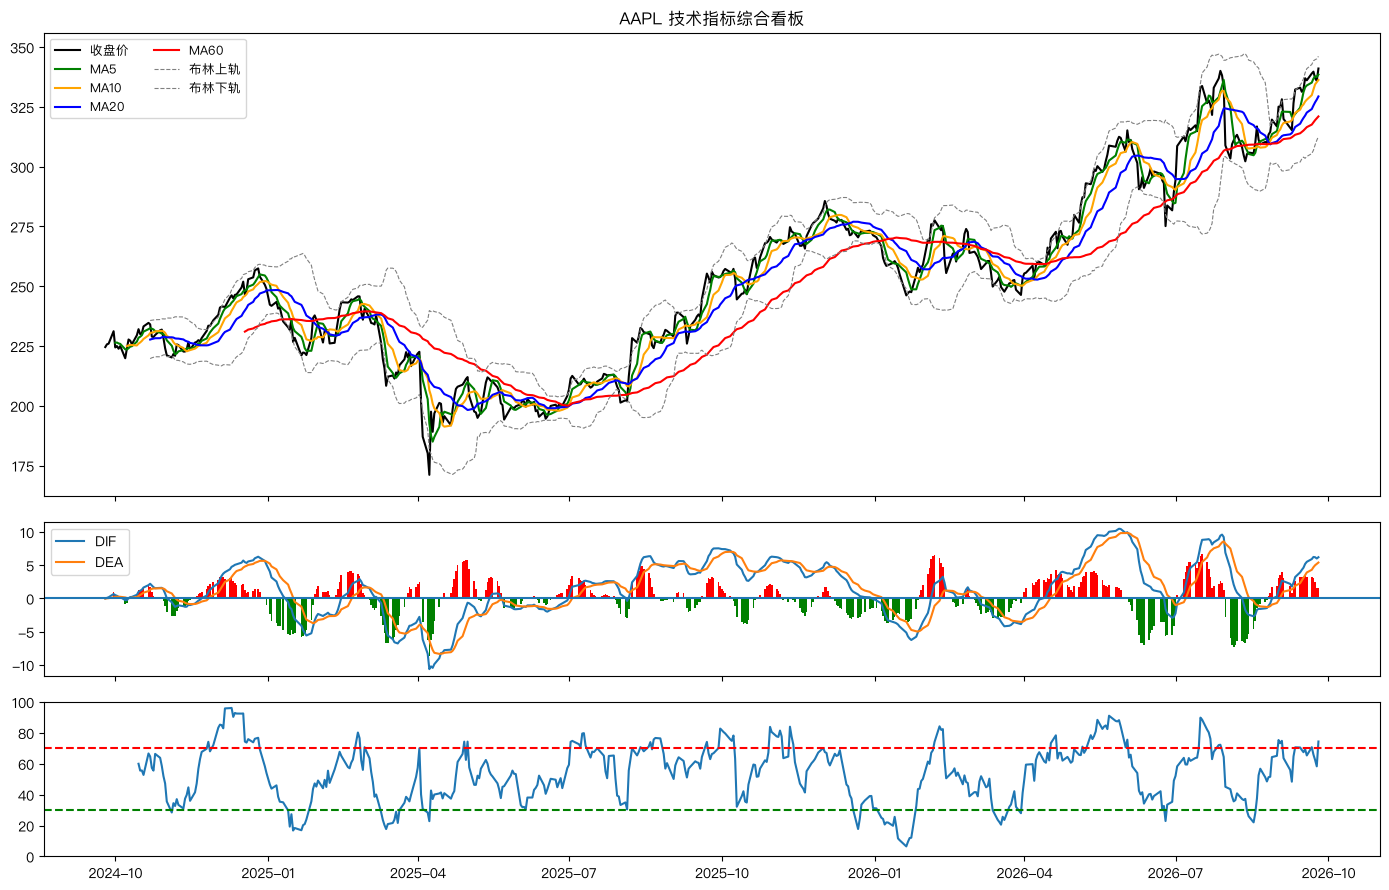

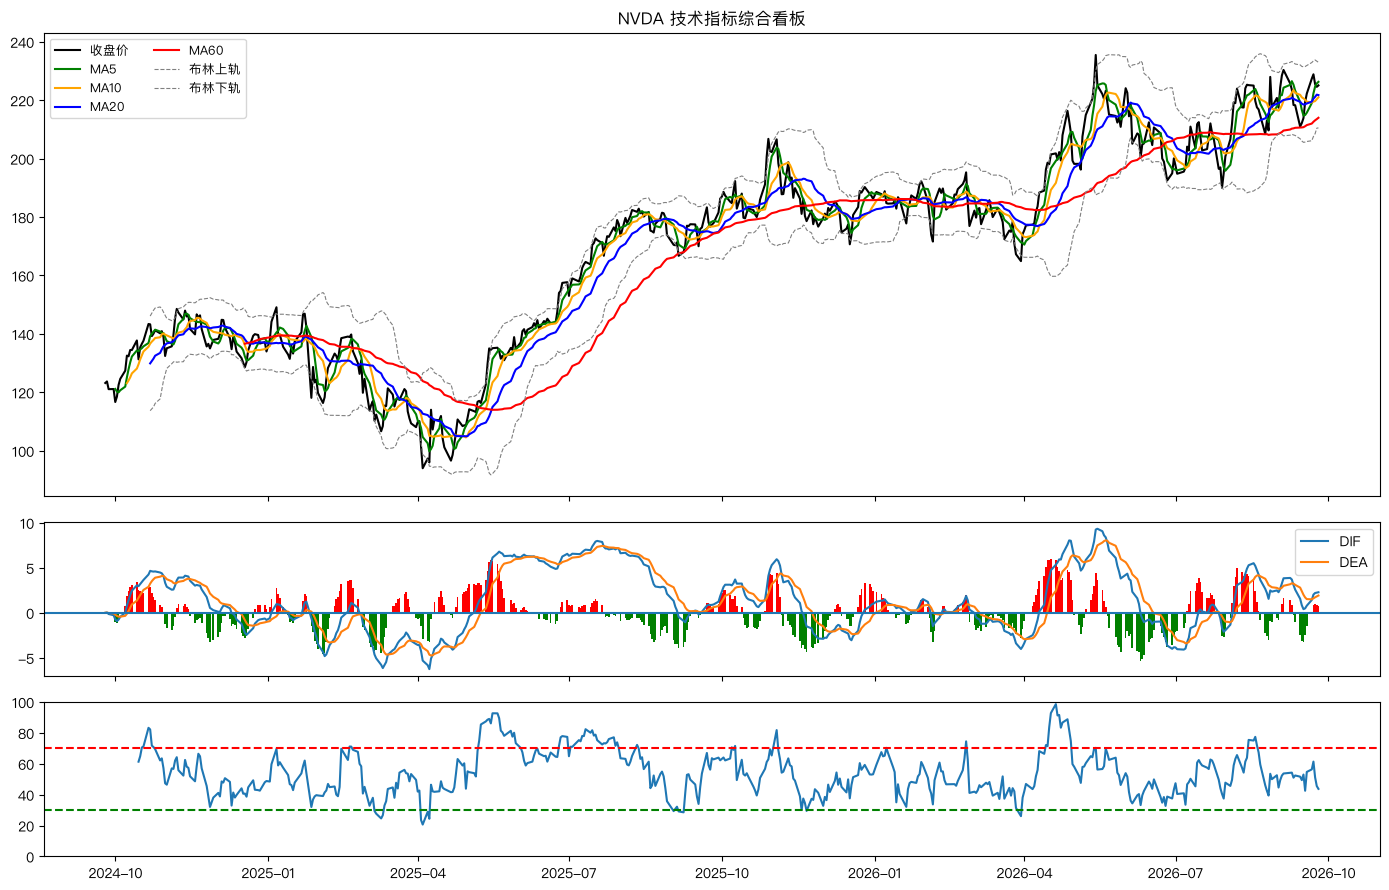

In [20]:
for name,d in stocks.items():
    fig,axes = plt.subplots(3, 1, figsize=(14,9), sharex=True,
                            gridspec_kw={'height_ratios':[3,1,1]})
    ax1,ax2,ax3 = axes

    # ---- 主图 ----
    ax1.plot(d.index,d['close'],label='收盘价',color='black')
    ax1.plot(d.index,d['MA5'],label='MA5',color='green')
    ax1.plot(d.index, d['MA10'], label='MA10', color='orange')
    ax1.plot(d.index, d['MA20'], label='MA20', color='blue')
    ax1.plot(d.index, d['MA60'], label='MA60', color='red')
    ax1.plot(d.index, d['BOLL_UP'],  label='布林上轨', color='gray', linewidth=0.8, linestyle='--')
    ax1.plot(d.index, d['BOLL_DN'],  label='布林下轨', color='gray', linewidth=0.8, linestyle='--')
    ax1.set_title(f'{name} 技术指标综合看板')
    ax1.legend(ncol=2, fontsize=9)

    # ---- 副图1：MACD ----
    ax2.plot(d.index,d['DIF'],label='DIF')
    ax2.plot(d.index,d['DEA'],label='DEA')   # DIF 线 + DEA 线
    colors = ['red' if v >= 0 else 'green' for v in d['MACD']]
    ax2.bar(d.index, d['MACD'], color=colors, width=1.0)    # MACD 柱状图
    ax2.axhline(y=0)        # 零轴
    ax2.legend()

    # ---- 副图2：RSI ----
    ax3.plot(d.index,d['RSI14'])    # RSI14 线
    ax3.axhline(y=70,linestyle='--',color = 'red')       # 超买线
    ax3.axhline(y=30,linestyle='--',color = 'green')       # 超卖线
    ax3.set_ylim(0, 100)


    plt.tight_layout()
    plt.savefig(f'/Users/macbookpro/Desktop/股/day33/{name}_看板.png', dpi=120)
    plt.show()

      累计收益率%  日波动率%  最大单日涨幅%  最大单日跌幅%
股票                                   
宁德时代   51.52   2.66    18.70   -14.71
AAPL   51.88   1.82    15.45    -9.30
NVDA   82.69   2.78    18.78   -17.00
对齐后形状: (468, 3)
       宁德时代   AAPL   NVDA
宁德时代  1.000  0.056 -0.006
AAPL  0.056  1.000  0.290
NVDA -0.006  0.290  1.000


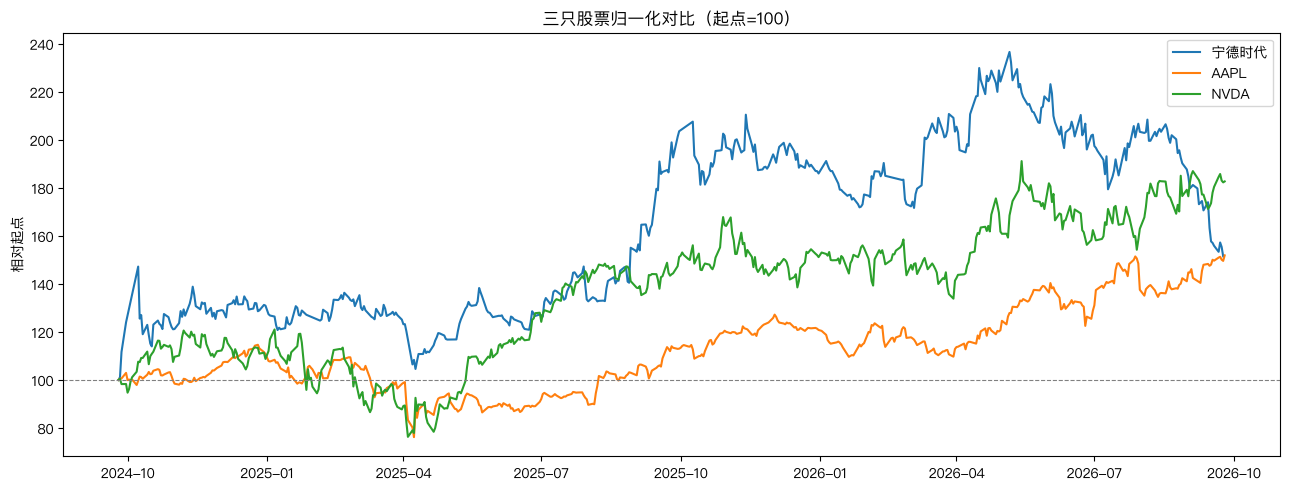

In [21]:
# ============================================================
# Day 33 —— ④ 对比三只股票表现
# ============================================================

# ---- 1. 各自算指标（不需要时间对齐）----
结果 = []
for name, d in stocks.items():
    日收益 = d['close'].pct_change()

    结果.append({
        '股票':          name,
        '累计收益率%':  (d['close'].iloc[-1] / d['close'].iloc[0] - 1) * 100,
        '日波动率%': 日收益.std() * 100,      # 日收益的标准差，×100
        '最大单日涨幅%': 日收益.max() * 100,      # 日收益的最大值，×100
        '最大单日跌幅%': 日收益.min() * 100,      # 日收益的最小值，×100
    })

对比表 = pd.DataFrame(结果).set_index('股票')
print(对比表.round(2))


# ---- 2. 归一化对比图 ----
fig, ax = plt.subplots(figsize=(13, 5))
for name, d in stocks.items():
    收盘 = d['close']
    归一 = 收盘 / 收盘.iloc[0] * 100      # 起点归一化到 100
    ax.plot(归一.index, 归一.values, label=name)

ax.axhline(y=100, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('三只股票归一化对比（起点=100）')
ax.set_ylabel('相对起点')
ax.legend()
plt.tight_layout()


# ---- 3. 相关性矩阵（必须时间对齐）----
收益率表 = pd.concat([d['close'].pct_change().rename(name)
                    for name, d in stocks.items()], axis=1,sort=False)
收益率表 = 收益率表.dropna()           # 丢掉落单的日子
print("对齐后形状:", 收益率表.shape)
print(收益率表.corr().round(3))

# 三只股票技术指标对比分析报告

  **分析区间**：2024-09-25 ~ 2026-09-25（约 2 年）
  **标的**：宁德时代(300750.SZ)、Apple(AAPL)、NVIDIA(NVDA)
  **数据源**：akshare（A股前复权 / 美股前复权）

  ## 一、区间表现对比

  | 标的 | 累计收益率 | 日波动率 | 最大单日涨幅 | 最大单日跌幅 |
  |------|-----------|---------|-------------|-------------|
  | 宁德时代 | +51.52% | 2.66% | +18.70% | −14.71% |
  | AAPL | +51.88% | 1.82% | +15.45% | −9.30% |
  | NVDA | +82.69% | 2.78% | +18.78% | −17.00% |

  **观察一：收益与波动同向。** NVDA 区间收益最高（+82.69%），但其
  日波动率（2.78%）与最大单日跌幅（−17.00%）同样为三者最高。宁德时
  代与 AAPL 累计收益几乎相同（51.52% vs 51.88%），但 AAPL 的日波动
  率（1.82%）比宁德时代（2.66%）低约 32%，最大单日跌幅（−9.30%）也
  明显更轻。**这说明仅凭收益率无法评价一只标的表现——同样的终点，路
  径的平稳程度差异巨大。**

  ## 二、技术指标分析

  ### 2.1 均线系统

  | 标的 | 多头排列天数 | 占比 | 空头排列天数 | 占比 |
  |------|------------|------|------------|------|
  | 宁德时代 | 143 | 29.4% | 111 | 22.8% |
  | AAPL | 184 | 36.7% | 104 | 20.7% |
  | NVDA | 165 | 32.9% | 102 | 20.3% |

  三者均呈现「多头排列天数 > 空头排列天数」，与区间正收益一致。
  AAPL 的多头排列占比最高（36.7%），趋势的持续性最强；宁德时代最低
  （29.4%），趋势切换更频繁。

  ### 2.2 MACD

  | 标的 | 金叉次数 | 死叉次数 |
  |------|---------|---------|
  | 宁德时代 | 19 | 19 |
  | AAPL | 19 | 18 |
  | NVDA | 23 | 22 |

  宁德时代的金叉与死叉次数完全相等（19:19），说明在该区间内多空力量
  基本均衡、以震荡为主。NVDA 信号总次数最多（45 次），价格波动更剧
  烈，指标反复穿越零轴。

  **需要特别注意**：金叉/死叉次数多≠机会多。信号越频繁，其中「假信号」
  的绝对数量通常也越多，且每次交易都会产生成本。

  ### 2.3 RSI(14)

  | 标的 | 超买(>70)天数 | 超卖(<30)天数 |
  |------|--------------|--------------|
  | 宁德时代 | 74 | 55 |
  | AAPL | 98 | 50 |
  | NVDA | 73 | 13 |

  AAPL 的超买天数最多（98 天，占 19.5%），符合其趋势持续性最强的特征
  ——强趋势中 RSI 会长期停留在高位，**此时 RSI 超买并不构成「应该卖
  出」的理由**。NVDA 的超卖天数最少（仅 13 天），说明其下跌往往急促而
  短暂。

  ### 2.4 布林带

  | 标的 | 突破上轨天数 | 跌破下轨天数 | 带外总占比 |
  |------|------------|------------|-----------|
  | 宁德时代 | 24 | 25 | 10.1% |
  | AAPL | 37 | 22 | 11.8% |
  | NVDA | 18 | 17 | 7.0% |

  **这是一个值得记录的现象。** 布林带设定为 ±2σ，若价格服从正态分布，
  理论上应有约 **5%** 的交易日落在带外。但三者实测值为 **7.0% ~ 11.8%**，
  全部显著高于理论值。

  **原因**：金融资产收益率并不服从正态分布，而是呈现「尖峰厚尾」
  （极端行情出现的频率远高于正态分布的预测）。这意味着**布林带在实战
  中会比理论更频繁地被突破**，把带外突破直接当作「反转信号」是危险的。

  ## 三、相关性分析

  基于 468 个共同交易日（已剔除 A股/美股休市日不一致的 51 天）：

  |  | 宁德时代 | AAPL | NVDA |
  |--|---------|------|------|
  | **宁德时代** | 1.000 | 0.056 | −0.006 |
  | **AAPL** | 0.056 | 1.000 | 0.290 |
  | **NVDA** | −0.006 | 0.290 | 1.000 |

  **这是本次分析最有价值的发现。** A股（宁德时代）与两只美股的相关性
  接近于零（0.056 / −0.006），即**它们的涨跌几乎互不影响**。而两只美股
  之间相关性为 0.290，属于弱相关。

  **含义**：若将资金同时配置于 A股与美股资产，在单一市场出现系统性下
  跌时，另一市场未必同步下跌，从而**降低整体组合的波动**——且因为相关
  性低而非负相关，长期收益不会被明显抵消。

  **关键认知：分散化的前提是「低相关」，而不是「数量多」。** 持有三只
  沪深300指数基金与持有一只无异；而持有相关性接近零的跨市场资产，才
  是真正的分散。

  ## 四、初步结论

  1. 三者区间内均为正收益，但收益与波动同向——**高收益伴随高波动**，
     不存在「收益高且平稳」的标的。
  2. AAPL 趋势持续性最强（多头排列占比 36.7%）、波动最低；NVDA 收益
     最高但波动与单日跌幅均最大；宁德时代居中，震荡特征最明显。
  3. 布林带实测带外比例（7%~11.8%）显著高于理论值（5%），印证了金融
     收益率的「厚尾」特征，**技术指标的阈值不能机械套用理论概率**。
  4. A股与美股相关性接近零，跨市场配置具备降低组合波动的数学基础。
  5. 长期领先 ≠ 最终胜出。
     宁德时代在 469 个共同交易日中有 **426 天（90.8%）**归一化收益高于NVDA——几乎全程领先。但最终 NVDA 以       182.3 反超宁德时代的 151.5。而反超只用了 9 个交易日：2026-09-14 之后，宁德时代从 174.0 跌至153.4，      NVDA 从 171.2 涨至 184.6。
     含义：两年的"胜率"可以被一周抹掉。用"多数时候更好"来判断一个标的，是有系统性缺陷的——决定最终收益的往往不       是平均表现，而是尾部那几次极端行情。

  ## 五、风险提示

  - 本报告基于**历史数据**，历史表现不代表未来收益。
  - 区间选择会显著影响结论：若取 2025 年单一年度，三者排序可能完全不同。
  - 技术指标均为**价格的滞后变换**，无法预测未来；指标冲突时（如 RSI
    超卖但 MACD 仍向下）不构成任何交易信号。
  - 未考虑交易成本、汇率波动、税费、流动性等因素；实盘收益会低于回测。
  - A股与美股存在汇率风险，美元资产的收益折算为人民币后会发生变化。

  ## 六、本报告的局限

  - 样本仅 3 只标的、2 年区间，**样本量过小**，结论不具备统计显著性。
  - 未做样本外验证，上述「规律」可能只是该区间的偶然特征（过拟合风险）。
  - 宁德时代为单只个股，不代表 A股整体；若改用沪深300指数，相关性结论
    可能不同。